In [2]:
# ============================================================
# STEP 1: INSTALLS + IMPORTS + CONFIG
# ============================================================
!pip install -q timm albumentations opencv-python

import os
import glob
import math
import time
import random
from dataclasses import dataclass

import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

@dataclass
class CFG:
    ROOT: str = "/kaggle/input/kvasir-seg/Kvasir-SEG"
    IMG_SIZE: int = 352
    BATCH_SIZE: int = 8
    EPOCHS: int = 50
    FREEZE_EPOCHS: int = 5
    PATIENCE: int = 12
    LR_ENCODER: float = 1e-5
    LR_OTHER: float = 1e-4
    WEIGHT_DECAY: float = 1e-4
    NUM_WORKERS: int = 2
    AMP: bool = True
    TEST_SIZE: float = 0.10
    VAL_SIZE: float = 0.10
    ENCODER_NAME: str = "convnext_tiny"
    PRETRAINED: bool = True
    SAVE_PATH: str = "/kaggle/working/best_hybrid_polyp_model.pth"
    W_EDGE: float = 0.20
    DS_WEIGHTS: tuple = (0.5, 0.3, 0.2)

cfg = CFG()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Root:", cfg.ROOT)

Device: cuda
Root: /kaggle/input/kvasir-seg/Kvasir-SEG


In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "images" in dirs and "masks" in dirs:
        print("FOUND ROOT:", root)
        print("Images path:", os.path.join(root, "images"))
        print("Masks path :", os.path.join(root, "masks"))
        break

FOUND ROOT: /kaggle/input/datasets/sahilnarang14/kvasir-seg/Kvasir-SEG
Images path: /kaggle/input/datasets/sahilnarang14/kvasir-seg/Kvasir-SEG/images
Masks path : /kaggle/input/datasets/sahilnarang14/kvasir-seg/Kvasir-SEG/masks


In [5]:
import os

def find_dataset_root(base="/kaggle/input"):
    for root, dirs, files in os.walk(base):
        if "images" in dirs and "masks" in dirs:
            return root
    raise FileNotFoundError("Could not find a folder containing both images and masks")

ROOT = find_dataset_root("/kaggle/input")
IMG_DIR = os.path.join(ROOT, "images")
MASK_DIR = os.path.join(ROOT, "masks")

print("ROOT    :", ROOT)
print("IMG_DIR :", IMG_DIR)
print("MASK_DIR:", MASK_DIR)
print("IMG exists:", os.path.exists(IMG_DIR))
print("MASK exists:", os.path.exists(MASK_DIR))

ROOT    : /kaggle/input/datasets/sahilnarang14/kvasir-seg/Kvasir-SEG
IMG_DIR : /kaggle/input/datasets/sahilnarang14/kvasir-seg/Kvasir-SEG/images
MASK_DIR: /kaggle/input/datasets/sahilnarang14/kvasir-seg/Kvasir-SEG/masks
IMG exists: True
MASK exists: True


In [6]:
def get_files(folder):
    files = []
    for f in os.listdir(folder):
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
            files.append(os.path.join(folder, f))
    return sorted(files)

def build_pairs(img_dir, mask_dir):
    img_files = sorted(get_files(img_dir))
    mask_files = sorted(get_files(mask_dir))

    print("Images:", len(img_files))
    print("Masks :", len(mask_files))

    assert len(img_files) == len(mask_files), "Mismatch in number of images and masks"
    return list(zip(img_files, mask_files))

pairs = build_pairs(IMG_DIR, MASK_DIR)
print("Total pairs:", len(pairs))
print("Sample pair:", pairs[0])

Images: 1000
Masks : 1000
Total pairs: 1000
Sample pair: ('/kaggle/input/datasets/sahilnarang14/kvasir-seg/Kvasir-SEG/images/cju0qkwl35piu0993l0dewei2.jpg', '/kaggle/input/datasets/sahilnarang14/kvasir-seg/Kvasir-SEG/masks/cju0qkwl35piu0993l0dewei2.jpg')


In [7]:
ROOT = "/kaggle/input/datasets/sahilnarang14/kvasir-seg/Kvasir-SEG"
IMG_DIR = ROOT + "/images"
MASK_DIR = ROOT + "/masks"

In [8]:
# ============================================================
# STEP 3: SPLIT + POSITIVE WEIGHT
# ============================================================
def mask_foreground_ratio(mask_path):
    m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(mask_path)
    m = (m > 127).astype(np.float32)
    return float(m.mean())

areas = np.array([mask_foreground_ratio(m) for _, m in pairs], dtype=np.float32)

quantiles = np.quantile(areas, [0.25, 0.50, 0.75])
bins = np.digitize(areas, quantiles, right=True)

try:
    train_pairs, temp_pairs, train_bins, temp_bins = train_test_split(
        pairs,
        bins,
        test_size=cfg.VAL_SIZE + cfg.TEST_SIZE,
        random_state=42,
        shuffle=True,
        stratify=bins
    )

    val_relative = cfg.VAL_SIZE / (cfg.VAL_SIZE + cfg.TEST_SIZE)
    val_pairs, test_pairs, _, _ = train_test_split(
        temp_pairs,
        temp_bins,
        test_size=(1 - val_relative),
        random_state=42,
        shuffle=True,
        stratify=temp_bins
    )
except ValueError:
    train_pairs, temp_pairs = train_test_split(
        pairs, test_size=cfg.VAL_SIZE + cfg.TEST_SIZE, random_state=42, shuffle=True
    )
    val_relative = cfg.VAL_SIZE / (cfg.VAL_SIZE + cfg.TEST_SIZE)
    val_pairs, test_pairs = train_test_split(
        temp_pairs, test_size=(1 - val_relative), random_state=42, shuffle=True
    )

print(f"Train: {len(train_pairs)}, Val: {len(val_pairs)}, Test: {len(test_pairs)}")

def compute_pos_weight(pairs_):
    pos_pixels = 0.0
    total_pixels = 0.0
    for _, mask_path in pairs_:
        m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        m = (m > 127).astype(np.float32)
        pos_pixels += float(m.sum())
        total_pixels += float(m.size)
    neg_pixels = total_pixels - pos_pixels
    ratio = neg_pixels / (pos_pixels + 1e-6)
    return float(np.clip(ratio, 1.0, 8.0))

pos_weight_value = compute_pos_weight(train_pairs)
print("pos_weight:", pos_weight_value)

Train: 800, Val: 100, Test: 100
pos_weight: 5.338340187828576


In [9]:
print(areas.min(), areas.max(), areas.mean())

0.004739269 0.81181973 0.15390989


In [10]:
# ============================================================
# STEP 4: TRANSFORMS + DATASET
# ============================================================
def get_train_transforms():
    return A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.10),
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.10,
            rotate_limit=20,
            border_mode=cv2.BORDER_REFLECT_101,
            p=0.50
        ),
        A.RandomBrightnessContrast(p=0.30),
        A.HueSaturationValue(p=0.20),
        A.CLAHE(p=0.20),
        A.OneOf([
            A.GaussNoise(p=1.0),
            A.MotionBlur(blur_limit=3, p=1.0),
            A.GaussianBlur(blur_limit=3, p=1.0),
        ], p=0.20),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])

class PolypDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(mask_path)
        mask = (mask > 127).astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].unsqueeze(0).float()
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).unsqueeze(0).float()

        return image, mask

train_ds = PolypDataset(train_pairs, transform=get_train_transforms())
val_ds   = PolypDataset(val_pairs, transform=get_val_transforms())
test_ds  = PolypDataset(test_pairs, transform=get_val_transforms())

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                          num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                        num_workers=cfg.NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                         num_workers=cfg.NUM_WORKERS, pin_memory=True)

batch = next(iter(train_loader))
print(batch[0].shape, batch[1].shape)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


torch.Size([8, 3, 352, 352]) torch.Size([8, 1, 352, 352])


In [13]:
# ============================================================
# STEP 5: MODEL BLOCKS
# ============================================================
def get_gn(ch, max_groups=8):
    g = min(max_groups, ch)
    while ch % g != 0 and g > 1:
        g -= 1
    return nn.GroupNorm(g, ch)

class ConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1, dropout=0.0):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p, bias=False)
        self.gn = get_gn(out_ch)
        self.act = nn.SiLU(inplace=True)
        self.drop = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return self.drop(self.act(self.gn(self.conv(x))))

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.1):
        super().__init__()
        self.conv1 = ConvGNAct(in_ch + skip_ch, out_ch, dropout=dropout)
        self.conv2 = ConvGNAct(out_ch, out_ch, dropout=dropout)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return x

class AttentionGate(nn.Module):
    def __init__(self, skip_ch, gating_ch, inter_ch):
        super().__init__()
        self.theta = nn.Sequential(
            nn.Conv2d(skip_ch, inter_ch, kernel_size=1, bias=False),
            get_gn(inter_ch)
        )
        self.phi = nn.Sequential(
            nn.Conv2d(gating_ch, inter_ch, kernel_size=1, bias=False),
            get_gn(inter_ch)
        )
        self.psi = nn.Sequential(
            nn.SiLU(inplace=True),
            nn.Conv2d(inter_ch, 1, kernel_size=1, bias=True),
            nn.Sigmoid()
        )

    def forward(self, skip, gating):
        s = self.theta(skip)
        g = self.phi(gating)
        g = F.interpolate(g, size=s.shape[-2:], mode="bilinear", align_corners=False)
        alpha = self.psi(s + g)
        return skip * alpha

class FixedSobel(nn.Module):
    def __init__(self):
        super().__init__()
        sobel_x = torch.tensor([[1, 0, -1],
                                [2, 0, -2],
                                [1, 0, -1]], dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[1, 2, 1],
                                [0, 0, 0],
                                [-1, -2, -1]], dtype=torch.float32).view(1, 1, 3, 3)
        self.register_buffer("sobel_x", sobel_x)
        self.register_buffer("sobel_y", sobel_y)

    def forward(self, x):
        if x.shape[1] > 1:
            x = x.mean(dim=1, keepdim=True)
        gx = F.conv2d(x, self.sobel_x, padding=1)
        gy = F.conv2d(x, self.sobel_y, padding=1)
        g = torch.sqrt(gx * gx + gy * gy + 1e-6)
        g = g / (g.amax(dim=(2, 3), keepdim=True) + 1e-6)
        return g

class LearnedEdgeConv(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        mid = max(in_ch // 2, 16)
        mid2 = max(in_ch // 4, 8)
        self.block = nn.Sequential(
            ConvGNAct(in_ch, mid, dropout=0.05),
            ConvGNAct(mid, mid2, dropout=0.05),
            nn.Conv2d(mid2, 1, kernel_size=1)
        )

    def forward(self, x):
        return self.block(x)

class BoundaryRefinementHead(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.sobel = FixedSobel()
        self.learned_edge = LearnedEdgeConv(in_ch)
        self.fuse = nn.Sequential(
            ConvGNAct(in_ch + 1, in_ch // 2, dropout=0.10),
            ConvGNAct(in_ch // 2, in_ch // 4, dropout=0.10),
            nn.Conv2d(in_ch // 4, 1, kernel_size=1)
        )

    def forward(self, feat):
        sobel_edge = self.sobel(feat)
        learned_edge = self.learned_edge(feat)
        edge = torch.sigmoid(sobel_edge + learned_edge)
        fused = torch.cat([feat, edge], dim=1)
        out = self.fuse(fused)
        return out, edge

class CrossAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads=4, dropout=0.1):
        super().__init__()
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim),
            nn.Dropout(dropout)
        )
        self.out_norm = nn.LayerNorm(dim)

    def forward(self, q_feat, kv_feat):
        B, C, H, W = q_feat.shape
        q = q_feat.flatten(2).transpose(1, 2)
        kv = kv_feat.flatten(2).transpose(1, 2)

        qn = self.norm_q(q)
        kvn = self.norm_kv(kv)

        out, _ = self.attn(qn, kvn, kvn, need_weights=False)
        out = out + qn
        out = self.out_norm(out + self.ffn(out))

        out = out.transpose(1, 2).view(B, C, H, W)
        return out

class CDM(nn.Module):
    def __init__(self, c_deep, c_shallow, out_ch=256):
        super().__init__()
        self.deep_proj = nn.Conv2d(c_deep, out_ch, kernel_size=1)
        self.shallow_proj = nn.Conv2d(c_shallow, out_ch, kernel_size=1)
        self.search = CrossAttentionBlock(dim=out_ch, num_heads=4, dropout=0.10)
        self.identify = nn.Sequential(
            ConvGNAct(out_ch * 2, out_ch, dropout=0.10),
            ConvGNAct(out_ch, out_ch, dropout=0.10)
        )
        self.pred = nn.Conv2d(out_ch, 1, kernel_size=1)

    def forward(self, deep_feat, shallow_feat):
        d = self.deep_proj(deep_feat)
        s = self.shallow_proj(shallow_feat)
        s = F.interpolate(s, size=d.shape[-2:], mode="bilinear", align_corners=False)

        searched = self.search(d, s)
        fused = torch.cat([searched, d], dim=1)
        identified = self.identify(fused)

        coarse_logit = self.pred(identified)
        miss = 1.0 - torch.sigmoid(coarse_logit)
        refined = identified + identified * miss
        return refined, coarse_logit

In [37]:
print("Blocks loaded")

Blocks loaded


In [14]:
# ============================================================
# STEP 6: FULL MODEL
# ============================================================
class HybridCamouflagePolypNet(nn.Module):
    def __init__(self, encoder_name="convnext_tiny", pretrained=True):
        super().__init__()
        self.encoder = timm.create_model(
            encoder_name,
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        chs = self.encoder.feature_info.channels()
        c1, c2, c3, c4 = chs

        self.cdm = CDM(c_deep=c4, c_shallow=c2, out_ch=256)

        self.ag3 = AttentionGate(skip_ch=c3, gating_ch=256, inter_ch=128)
        self.ag2 = AttentionGate(skip_ch=c2, gating_ch=256, inter_ch=128)
        self.ag1 = AttentionGate(skip_ch=c1, gating_ch=128, inter_ch=64)

        self.dec3 = DecoderBlock(in_ch=256, skip_ch=c3, out_ch=256, dropout=0.10)
        self.dec2 = DecoderBlock(in_ch=256, skip_ch=c2, out_ch=128, dropout=0.10)
        self.dec1 = DecoderBlock(in_ch=128, skip_ch=c1, out_ch=64, dropout=0.10)

        self.head_final = nn.Sequential(
            ConvGNAct(64, 32, dropout=0.10),
            nn.Conv2d(32, 1, kernel_size=1)
        )
        self.head_p3 = nn.Conv2d(256, 1, kernel_size=1)
        self.head_p2 = nn.Conv2d(128, 1, kernel_size=1)

        self.boundary = BoundaryRefinementHead(in_ch=64)

    def forward(self, x):
        f1, f2, f3, f4 = self.encoder(x)

        cdm_feat, coarse_logit = self.cdm(f4, f2)

        skip3 = self.ag3(f3, cdm_feat)
        d3 = self.dec3(cdm_feat, skip3)
        p3 = self.head_p3(d3)

        p3_up_f2 = F.interpolate(p3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
        ra2 = (1.0 - torch.sigmoid(p3_up_f2)) * f2
        skip2 = self.ag2(ra2, d3)
        d2 = self.dec2(d3, skip2)
        p2 = self.head_p2(d2)

        p2_up_f1 = F.interpolate(p2, size=f1.shape[-2:], mode="bilinear", align_corners=False)
        ra1 = (1.0 - torch.sigmoid(p2_up_f1)) * f1
        skip1 = self.ag1(ra1, d2)
        d1 = self.dec1(d2, skip1)

        boundary_logit, edge_feat = self.boundary(d1)

        final_logit = self.head_final(d1) + boundary_logit

        final_logit = F.interpolate(final_logit, size=x.shape[-2:], mode="bilinear", align_corners=False)
        p3 = F.interpolate(p3, size=x.shape[-2:], mode="bilinear", align_corners=False)
        p2 = F.interpolate(p2, size=x.shape[-2:], mode="bilinear", align_corners=False)
        coarse_logit = F.interpolate(coarse_logit, size=x.shape[-2:], mode="bilinear", align_corners=False)
        boundary_logit = F.interpolate(boundary_logit, size=x.shape[-2:], mode="bilinear", align_corners=False)

        return {
            "final": final_logit,
            "p3": p3,
            "p2": p2,
            "coarse": coarse_logit,
            "boundary": boundary_logit,
        }

model = HybridCamouflagePolypNet(
    encoder_name=cfg.ENCODER_NAME,
    pretrained=cfg.PRETRAINED
).to(device)

print("Model built.")

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Model built.


In [15]:
x = torch.randn(2, 3, cfg.IMG_SIZE, cfg.IMG_SIZE).to(device)
y = model(x)
for k, v in y.items():
    print(k, v.shape)

final torch.Size([2, 1, 352, 352])
p3 torch.Size([2, 1, 352, 352])
p2 torch.Size([2, 1, 352, 352])
coarse torch.Size([2, 1, 352, 352])
boundary torch.Size([2, 1, 352, 352])


In [17]:
# ============================================================
# STEP 7: LOSS + METRICS
# ============================================================
def dice_loss_with_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (probs * targets).sum(dim=1)
    denom = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2.0 * intersection + eps) / (denom + eps)
    return 1.0 - dice.mean()

class HybridLoss(nn.Module):
    def __init__(self, pos_weight_value, ds_weights=(0.5, 0.3, 0.2)):
        super().__init__()
        self.ds_weights = ds_weights
        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
        )
        self.sobel = FixedSobel().to(device)

    def seg_loss(self, logits, targets):
        bce = self.bce(logits, targets)
        dice = dice_loss_with_logits(logits, targets)
        return 0.5 * bce + 0.5 * dice

    def forward(self, outputs, targets):
        targets = targets.float().clamp(0.0, 1.0)

        main_loss = self.seg_loss(outputs["final"], targets)
        aux_loss = (
            self.ds_weights[0] * self.seg_loss(outputs["p3"], targets) +
            self.ds_weights[1] * self.seg_loss(outputs["p2"], targets) +
            self.ds_weights[2] * self.seg_loss(outputs["coarse"], targets)
        )

        edge_t = self.sobel(targets)
        boundary_prob = torch.sigmoid(outputs["boundary"])
        boundary_loss = F.l1_loss(boundary_prob, edge_t)

        total = main_loss + 0.40 * aux_loss + cfg.W_EDGE * boundary_loss
        return total

criterion = HybridLoss(pos_weight_value=pos_weight_value, ds_weights=cfg.DS_WEIGHTS).to(device)

class SegMeter:
    def __init__(self, threshold=0.5, eps=1e-7):
        self.threshold = threshold
        self.eps = eps
        self.reset()

    def reset(self):
        self.tp = 0.0
        self.fp = 0.0
        self.fn = 0.0
        self.tn = 0.0

    @torch.no_grad()
    def update(self, logits, targets):
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).float()
        targets = targets.float()

        self.tp += (preds * targets).sum().item()
        self.fp += (preds * (1 - targets)).sum().item()
        self.fn += ((1 - preds) * targets).sum().item()
        self.tn += ((1 - preds) * (1 - targets)).sum().item()

    def compute(self):
        iou = self.tp / (self.tp + self.fp + self.fn + self.eps)
        dice = (2 * self.tp) / (2 * self.tp + self.fp + self.fn + self.eps)
        precision = self.tp / (self.tp + self.fp + self.eps)
        recall = self.tp / (self.tp + self.fn + self.eps)
        accuracy = (self.tp + self.tn) / (self.tp + self.tn + self.fp + self.fn + self.eps)
        return {
            "iou": iou,
            "dice": dice,
            "precision": precision,
            "recall": recall,
            "accuracy": accuracy
        }

print("Loss and metrics ready.")

Loss and metrics ready.


In [18]:
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)
out = model(images)
loss = criterion(out, masks)
print(loss.item())

1.4476954936981201


In [19]:
# ============================================================
# STEP 8: OPTIMIZER + SCHEDULER
# ============================================================
def set_encoder_trainable(model, trainable=True):
    for p in model.encoder.parameters():
        p.requires_grad = trainable

def build_optimizer(model):
    encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
    other_params = []
    for name, p in model.named_parameters():
        if not name.startswith("encoder.") and p.requires_grad:
            other_params.append(p)

    optimizer = torch.optim.AdamW(
        [
            {"params": encoder_params, "lr": cfg.LR_ENCODER},
            {"params": other_params, "lr": cfg.LR_OTHER},
        ],
        weight_decay=cfg.WEIGHT_DECAY,
        betas=(0.9, 0.999),
        eps=1e-8
    )
    return optimizer

class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.min_lr = min_lr
        self.epoch = 0
        for group in self.optimizer.param_groups:
            group["initial_lr"] = group["lr"]

    def step(self):
        self.epoch += 1
        for group in self.optimizer.param_groups:
            base_lr = group["initial_lr"]
            if self.epoch <= self.warmup_epochs:
                lr = base_lr * self.epoch / self.warmup_epochs
            else:
                progress = (self.epoch - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
                lr = self.min_lr + 0.5 * (base_lr - self.min_lr) * (1.0 + math.cos(math.pi * progress))
            group["lr"] = lr

set_encoder_trainable(model, trainable=False)
optimizer = build_optimizer(model)
scheduler = WarmupCosineScheduler(
    optimizer=optimizer,
    warmup_epochs=cfg.FREEZE_EPOCHS,
    total_epochs=cfg.EPOCHS,
    min_lr=1e-6
)
scaler = torch.cuda.amp.GradScaler(enabled=cfg.AMP)

print("Optimizer ready.")

Optimizer ready.


/tmp/ipykernel_55/2129804637.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.AMP)


In [20]:
# ============================================================
# STEP 9: TRAIN / EVAL
# ============================================================
def train_one_epoch(model, loader, optimizer, scaler, criterion, threshold=0.5, grad_clip=1.0):
    model.train()
    loss_sum = 0.0
    meter = SegMeter(threshold=threshold)

    for images, masks in tqdm(loader, desc="Train", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=cfg.AMP):
            outputs = model(images)
            loss = criterion(outputs, masks)

        if cfg.AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        loss_sum += loss.item()
        meter.update(outputs["final"], masks)

    return loss_sum / max(1, len(loader)), meter.compute()

@torch.no_grad()
def evaluate(model, loader, criterion, threshold=0.5):
    model.eval()
    loss_sum = 0.0
    meter = SegMeter(threshold=threshold)

    for images, masks in tqdm(loader, desc="Eval", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=cfg.AMP):
            outputs = model(images)
            loss = criterion(outputs, masks)

        loss_sum += loss.item()
        meter.update(outputs["final"], masks)

    return loss_sum / max(1, len(loader)), meter.compute()

@torch.no_grad()
def visualize_predictions(model, loader, threshold=0.5, n=3):
    import matplotlib.pyplot as plt

    model.eval()
    images, masks = next(iter(loader))
    images = images.to(device)
    masks = masks.to(device)

    outputs = model(images)
    probs = torch.sigmoid(outputs["final"])
    preds = (probs > threshold).float()

    images = images.cpu().permute(0, 2, 3, 1).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    images = (images * std + mean).clip(0, 1)

    masks = masks.cpu().numpy()
    preds = preds.cpu().numpy()

    n = min(n, images.shape[0])
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(masks[i, 0], cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(preds[i, 0], cmap="gray")
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

print("Train/eval functions ready.")

Train/eval functions ready.


In [21]:
# ============================================================
# STEP 10: TRAINING LOOP
# ============================================================
best_val_dice = -1.0
best_val_threshold = 0.5
patience = 0

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": [],
    "train_dice": [],
    "val_dice": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
}

for epoch in range(1, cfg.EPOCHS + 1):
    start_time = time.time()

    if epoch == cfg.FREEZE_EPOCHS + 1:
        set_encoder_trainable(model, trainable=True)
        optimizer = build_optimizer(model)
        scheduler = WarmupCosineScheduler(
            optimizer=optimizer,
            warmup_epochs=cfg.FREEZE_EPOCHS,
            total_epochs=cfg.EPOCHS,
            min_lr=1e-6
        )
        scaler = torch.cuda.amp.GradScaler(enabled=cfg.AMP)
        print("\nUnfroze encoder.\n")

    train_loss, train_metrics = train_one_epoch(
        model, train_loader, optimizer, scaler, criterion, threshold=0.5, grad_clip=1.0
    )
    val_loss, val_metrics = evaluate(model, val_loader, criterion, threshold=0.5)

    scheduler.step()

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_metrics["iou"])
    history["val_iou"].append(val_metrics["iou"])
    history["train_dice"].append(train_metrics["dice"])
    history["val_dice"].append(val_metrics["dice"])
    history["train_precision"].append(train_metrics["precision"])
    history["val_precision"].append(val_metrics["precision"])
    history["train_recall"].append(train_metrics["recall"])
    history["val_recall"].append(val_metrics["recall"])

    elapsed = time.time() - start_time
    print(
        f"Epoch [{epoch:03d}/{cfg.EPOCHS}] "
        f"Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | "
        f"Train Dice {train_metrics['dice']:.4f} | Val Dice {val_metrics['dice']:.4f} | "
        f"Time {elapsed:.1f}s"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        best_val_threshold = 0.5
        patience = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "best_val_dice": best_val_dice,
            "best_val_threshold": best_val_threshold,
            "cfg": cfg.__dict__
        }, cfg.SAVE_PATH)
        print(f"Saved best model to {cfg.SAVE_PATH}")
    else:
        patience += 1
        print(f"No improvement. Patience {patience}/{cfg.PATIENCE}")

    if patience >= cfg.PATIENCE:
        print("Early stopping triggered.")
        break

Train:   0%|          | 0/100 [00:00<?, ?it/s]/tmp/ipykernel_55/2385446319.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.AMP):
Eval:   0%|          | 0/13 [00:00<?, ?it/s]           /tmp/ipykernel_55/2385446319.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.AMP):


Epoch [001/50] Train Loss 0.9520 | Val Loss 0.7396 | Train Dice 0.6167 | Val Dice 0.6886 | Time 21.2s
Saved best model to /kaggle/working/best_hybrid_polyp_model.pth


Epoch [002/50] Train Loss 0.7566 | Val Loss 0.6949 | Train Dice 0.7345 | Val Dice 0.8114 | Time 10.3s
Saved best model to /kaggle/working/best_hybrid_polyp_model.pth


Epoch [003/50] Train Loss 0.7374 | Val Loss 0.6642 | Train Dice 0.7480 | Val Dice 0.8108 | Time 10.4s
No improvement. Patience 1/12


Epoch [004/50] Train Loss 0.7335 | Val Loss 0.6101 | Train Dice 0.7432 | Val Dice 0.8221 | Time 10.3s
Saved best model to /kaggle/working/best_hybrid_polyp_model.pth


...

Epoch [046/50] Train Loss 0.1179 | Val Loss 0.4374 | Train Dice 0.9623 | Val Dice 0.9090 | Time 18.6s
No improvement. Patience 4/12


Epoch [047/50] Train Loss 0.1174 | Val Loss 0.4188 | Train Dice 0.9611 | Val Dice 0.9087 | Time 18.6s
No improvement. Patience 5/12


Epoch [048/50] Train Loss 0.1341 | Val Loss 0.4037 | Train Dice 0.9594 | Val Dice 0.9085 | Time 18.5s
No improvement. Patience 6/12


Epoch [049/50] Train Loss 0.1156 | Val Loss 0.4302 | Train Dice 0.9617 | Val Dice 0.9095 | Time 18.6s
No improvement. Patience 7/12


Epoch [050/50] Train Loss 0.1103 | Val Loss 0.4573 | Train Dice 0.9607 | Val Dice 0.9096 | Time 18.6s
No improvement. Patience 8/12


In [22]:
# ============================================================
# STEP 11: TEST EVALUATION
# ============================================================
checkpoint = torch.load(cfg.SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print("Loaded best checkpoint from epoch:", checkpoint["epoch"])
print("Best validation Dice:", checkpoint["best_val_dice"])

test_loss, test_metrics = evaluate(model, test_loader, criterion, threshold=0.5)

print("\n=== TEST RESULTS ===")
print(f"Loss      : {test_loss:.4f}")
print(f"IoU       : {test_metrics['iou']:.4f}")
print(f"Dice/F1   : {test_metrics['dice']:.4f}")
print(f"Precision : {test_metrics['precision']:.4f}")
print(f"Recall    : {test_metrics['recall']:.4f}")
print(f"Accuracy  : {test_metrics['accuracy']:.4f}")

Loaded best checkpoint from epoch: 42
Best validation Dice: 0.9104045357808358


Eval:   0%|          | 0/13 [00:00<?, ?it/s]/tmp/ipykernel_55/2385446319.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.AMP):
                                                     


=== TEST RESULTS ===
Loss      : 0.4023
IoU       : 0.8381
Dice/F1   : 0.9119
Precision : 0.9251
Recall    : 0.8991
Accuracy  : 0.9732


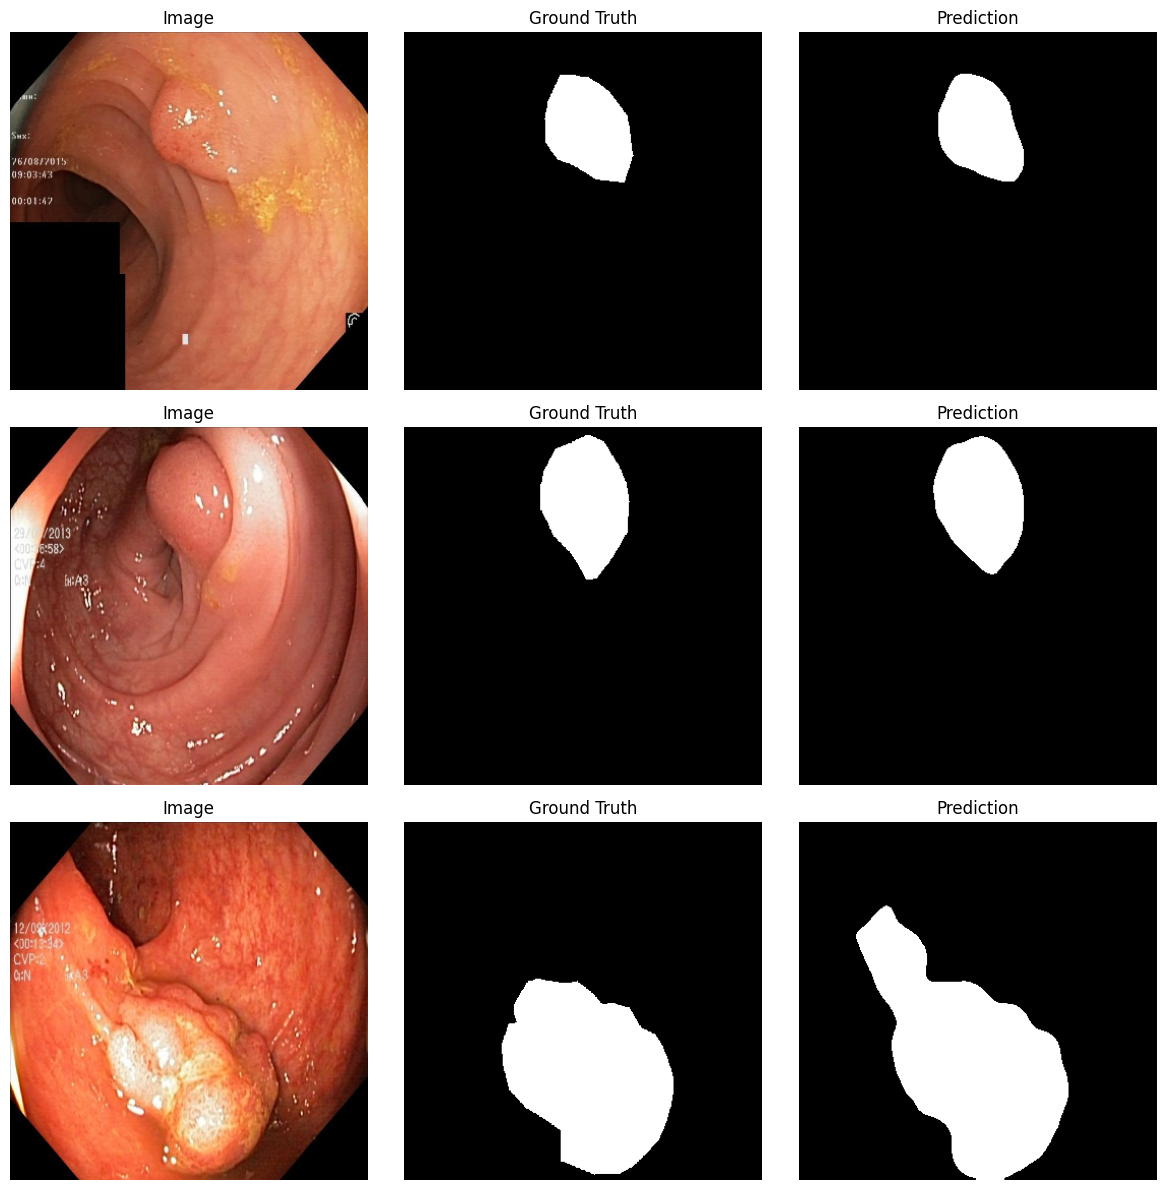

Saved training history to /kaggle/working/training_history.csv


In [23]:
# ============================================================
# STEP 12: VISUALIZATION + SAVE HISTORY
# ============================================================
visualize_predictions(model, test_loader, threshold=0.5, n=3)

hist_df = pd.DataFrame(history)
hist_df.to_csv("/kaggle/working/training_history.csv", index=False)
print("Saved training history to /kaggle/working/training_history.csv")